## $\chi^2$ optimization for the full waterfall plot

In [10]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

from import_list import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# File name
print ('File name: '+param.file_name)

# Time of observation
tools.timepoint(fname=int(param.file_name), date=None)
 
# Katdal information
katdal_info = pickle.load(open(param.telescope_info_path, 'rb'), encoding='latin1')
info = [katdal_info[i] for i in katdal_info.keys()]
nd_s0=katdal_info['nd_s0']
nd_s0_coords=katdal_info['nd_s0_coords']
frequency=katdal_info['frequency']

# Frequency start and end point
print ('\nFrequency range from {fs}-{fe} MHz'.format(fs=param.fs, fe=param.fe))

# Bias count for number of constellations
bias = np.ones(len(param.constellations))

# Folder for saving the current work (eg: yyyy_mm_dd)
print ('Folder for saving data is: '+param.work_folder)

# Frequency band inside the frequency range  [MHz]
fband_s, fband_e = 1100, 1350

Date of observation: 2019-02-25 02:40:11
Fname: 1551055211

Frequency range from 1000-1500 MHz
Folder for saving data is: parallel_2022_03_20


In [3]:
# Initalizing the class 
sat = ss(file_name=param.file_name, 
         sats_only=None, 
         data_loc=param.meerkat_data, 
         sat_loc=param.meerkat_data,
         survey_info=[nd_s0, nd_s0_coords, frequency], 
         sat_info=param.satellite_catalogue,
         plots_loc=param.save_plots,
         sat_beam=param.beam_model, 
         frequency_range=[param.fs,param.fe], 
         constellations=param.constellations, 
         nearby_satellites=param.nearby_constellation_fpath)


# Creating random alpha values for the inital excecution
np.random.seed()
dic = 10*np.random.random(sat.alpha_len)

# Running the excecution
sat.excecute(a_param=dic,
             obs_time_start=nd_s0[0], obs_time_end=nd_s0[-1], 
             obs_frequency_start=fband_s, obs_frequency_end=fband_e, 
             file_bias_choice=bias, 
             add_sub=[1, 1],
             band_lvl=[None, None], 
             bandsize=None)

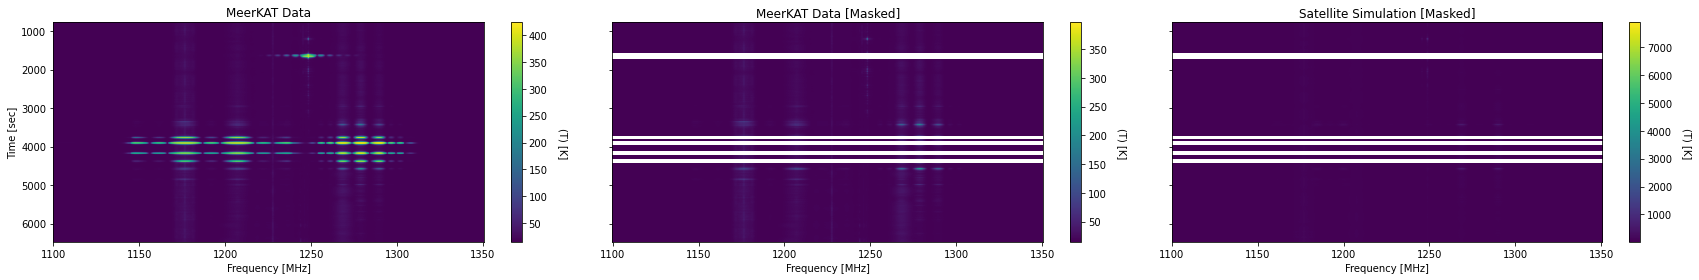

In [4]:
extent = [sat.frequency_band[sat.frequency_idx[0]], sat.frequency_band[sat.frequency_idx[1]],\
            sat.nd_s0[sat.time_idx[1]], sat.nd_s0[sat.time_idx[0]]]

masked_sim_sat = np.ma.array(data=sat.simulation_TOD_slice, mask=sat.mask_nearby_satellites_slice.T)
masked_data_sat = np.ma.array(data=sat.calibration_data_slice, mask=sat.mask_nearby_satellites_slice.T)


waterfall = [sat.calibration_data_slice, masked_data_sat, masked_sim_sat]
waterfall_name = ['MeerKAT Data', 'MeerKAT Data [Masked]', 'Satellite Simulation [Masked]' ]

fig, axs = plt.subplots(1, 3, figsize=(24,4), sharey=True)
fig.subplots_adjust()

for plot in range(3):
    ax=axs[plot]

    hb = ax.imshow(waterfall[plot].T, aspect='auto', extent=extent)
    ax.set_title(waterfall_name[plot])
    cbar = plt.colorbar(hb,ax=ax)
    cbar.set_label(r'(T) [K]', rotation=270, labelpad=20, y=0.45)

    if plot==0:
        ax.set_ylabel('Time [sec]')
    ax.set_xlabel('Frequency [MHz]')

    
plt.tight_layout()
plt.show()

In [5]:
def radiometer_eq(data):
    '''
    Radiometer euquation for determining the error on the data
    '''
    d_nu = 0.2 * 10**6 # Hz
    d_t = 2 # s
    n_pol = 2 
    n_dish = 58
    sig2 = data**2 / (n_pol*d_nu*d_t*n_dish)
    sig = np.sqrt(sig2)
    
    return sig


In [6]:
# Chi^2 for the optimzation case
def chisq_func2(a_param):
    """
    Chi2 function which will take in all the parameters for the satellites
    """

    sat.excecute(a_param, 
                 obs_time_start=nd_s0[0], obs_time_end=nd_s0[-1], 
                 obs_frequency_start=fband_s, obs_frequency_end=fband_e, 
                 file_bias_choice=bias, 
                 add_sub=[1, 1], 
                 band_lvl=[None, None], 
                 bandsize=None)


    # Masking the simulation and data using masked array values
    simulation = np.ma.array(data=sat.simulation_TOD_slice, mask=sat.mask_nearby_satellites_slice.T)
    data = np.ma.array(data=sat.calibration_data_slice, mask=sat.mask_nearby_satellites_slice.T)
    
    # Applying the sigma using the radiometer equation
    sig = radiometer_eq(data=data)    

    # Chi^2 equation
    chi_sq = np.ma.sum( (simulation - data )**2 / sig**2)
    return chi_sq

In [7]:
# Setting the bound values for the optimization
bnd_val = (0.0, 30)
bnds = [bnd_val for bnd_i in range(sat.alpha_len)]

In [8]:
# Running the optimization
print ('Running optimization')
signal_PL = opt.minimize(fun=chisq_func2,          # The chi^2 equation for optimization
                         x0=dic,                   # The param values for the optimzation
                         method='Powell',          # The method of choice in the optimization
                         bounds=bnds,              # Bound values for the optimization
                         tol=1e-6,                 # Tolerance value
                         options={'maxiter':20})

Running optimization


KeyboardInterrupt: 

In [ ]:
# Initializing the class a second time tp excecute with the best fit values

print ('Running 2nd init')

sat2 = ss(file_name=param.file_name, 
          sats_only=None, 
          data_loc=param.meerkat_data, 
          sat_loc=param.meerkat_data,
          survey_info=[nd_s0, nd_s0_coords, frequency], 
          sat_info=param.satellite_catalogue,
          plots_loc=param.save_plots,
          sat_beam=param.beam_model, 
          frequency_range=[param.fs,param.fe], 
          constellations=param.constellations, 
          nearby_satellites=param.nearby_constellation_fpath)


sat2.excecute(a_param=signal_PL.x,                                          # Applying the best-fit paramaters
              obs_time_start=nd_s0[0], obs_time_end=nd_s0[-1], 
              obs_frequency_start=fband_s, obs_frequency_end=fband_e, 
              file_bias_choice=bias,
              add_sub=[1, 1], 
              band_lvl=[None, None], 
              bandsize=None)

In [ ]:
# Storing the data in a  dictionary file

data_info = {'initial':dic,                                                 # Intial parameter test
             'time': sat.nd_s0[0:-1],                                       # The time range for the observation
             'best-fit':signal_PL.x,                                        # Best_fit from the optimization 
             'chi2_value':signal_PL.fun,                                    # The chi^2 value
             'chi2_div':signal_PL.fun/sat2.simulation_TOD_slice.size        # chi^2 value divided by number of data points
}

# pickle.dump(data_info, open(param.chi2_save_data+'/data_test_full_mask_full.p', 'wb'))



    